# Sentiment Analysis Model

Model: roberta-base

Fine-tuned on: Financial PhraseBank (3-class: negative / neutral / positive)

Applied to: full articles (title + clean_text)

Output: per-article probs + sentiment_score = P(pos) − P(neg)

Artifacts: /content/sent_roberta_phrasebank/best_model (what you called sent_roberta_phrasebank)

In [ ]:
from datasets import load_dataset

# Load the highest-agreement configuration
ds = load_dataset("takala/financial_phrasebank", "sentences_allagree")

print(ds)
print(ds["train"][0])



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})
{'sentence': 'According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .', 'label': 1}


In [ ]:
from datasets import ClassLabel
from collections import Counter

# 1) Check label names (PhraseBank uses 0/1/2; names may be embedded as ClassLabel)
print("Features:", ds["train"].features)

# 2) Build a stratified split (keeps label proportions)
split = ds["train"].train_test_split(test_size=0.15, seed=42, stratify_by_column="label")
train_ds = split["train"]
val_ds   = split["test"]

print("Train size:", len(train_ds), "Val size:", len(val_ds))
print("Train label dist:", Counter(train_ds["label"]))
print("Val label dist:  ", Counter(val_ds["label"]))

# 3) Define label maps for the model
ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
print("ID2LABEL:", ID2LABEL)

Features: {'sentence': Value(dtype='string', id=None), 'label': ClassLabel(names=['negative', 'neutral', 'positive'], id=None)}
Train size: 1924 Val size: 340
Train label dist: Counter({1: 1182, 2: 484, 0: 258})
Val label dist:   Counter({1: 209, 2: 86, 0: 45})
ID2LABEL: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [ ]:
import datasets, transformers, huggingface_hub

print("datasets:", datasets.__version__)
print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 2.21.0
transformers: 5.2.0
huggingface_hub: 1.3.0


In [ ]:
from transformers import AutoTokenizer
from datasets import DatasetDict

BASE_MODEL = "roberta-base"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)

def tokenize_batch(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        max_length=MAX_LEN,
    )

train_tok = train_ds.map(tokenize_batch, batched=True, remove_columns=["sentence"])
val_tok   = val_ds.map(tokenize_batch, batched=True, remove_columns=["sentence"])

data = DatasetDict(train=train_tok, validation=val_tok)

print(data)
print("Tokenized columns:", data["train"].column_names)
print("Example:", {k: data['train'][0][k] for k in ['label','input_ids','attention_mask']})

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1924
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 340
    })
})
Tokenized columns: ['label', 'input_ids', 'attention_mask']
Example: {'label': 0, 'input_ids': [0, 1225, 830, 1824, 111, 21533, 14978, 2104, 4403, 468, 5655, 2331, 17311, 267, 39509, 4832, 11790, 43227, 26, 452, 14, 63, 1161, 872, 23398, 7, 10353, 306, 479, 398, 475, 11, 5, 78, 457, 9, 1824, 31, 10353, 176, 479, 246, 475, 11, 5, 12337, 675, 10, 76, 656, 479, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


# Initialize roberta-base classifier + fine-tune

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

set_seed(42)

ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

args = TrainingArguments(
    output_dir="/content/sent_roberta_phrasebank",
    seed=42,
    data_seed=42,

    learning_rate=2e-5,
    num_train_epochs=2,

    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=64,

    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    logging_strategy="steps",
    logging_steps=25,

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    fp16=True,
    weight_decay=0.01,
    warmup_ratio=0.06,

    save_total_limit=2,
    report_to=["none"],

    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=data["train"],
    eval_dataset=data["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
)

trainer.train()
metrics = trainer.evaluate()
print("Final validation metrics:", metrics)

trainer.save_model("/content/sent_roberta_phrasebank/best_model")
tokenizer.save_pretrained("/content/sent_roberta_phrasebank/best_model")
print("Saved to: /content/sent_roberta_phrasebank/best_model")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
100,0.486348,0.159157,0.958824,0.942283,0.958732


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Final validation metrics: {'eval_loss': 0.1589188575744629, 'eval_accuracy': 0.9588235294117647, 'eval_f1_macro': 0.9422830927151947, 'eval_f1_weighted': 0.9587321939439343, 'eval_runtime': 0.3555, 'eval_samples_per_second': 956.484, 'eval_steps_per_second': 16.879, 'epoch': 2.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/sent_roberta_phrasebank/best_model


# batch inference on your 200k news articles

In [ ]:
import pandas as pd
from google.colab import drive

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

df = pd.read_parquet(
    "/content/drive/MyDrive/NLP Final Project/docs_with_topics.parquet"
)

Mounted at /content/drive


In [ ]:
print(type(df))
print(len(df))
print(df.columns)
df.head(2)

<class 'pandas.core.frame.DataFrame'>
183369
Index(['url', 'date', 'title', 'clean_text', 'topic', 'topic_name'], dtype='object')


,url,date,title,clean_text,topic,topic_name
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",68,None
1,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation Mode...,-1,Outliers


In [ ]:
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm
from pathlib import Path

# ---------- Config ----------
MODEL_DIR = Path("/content/sent_roberta_phrasebank/best_model")  # where Step 5 saved
BASE_MODEL = "roberta-base"
MAX_LEN = 256
BATCH_SIZE = 64  # T4-safe; you can try 96/128 later if you want

ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}

# ---------- Load model/tokenizer ----------
if MODEL_DIR.exists():
    tokenizer_inf = AutoTokenizer.from_pretrained(str(MODEL_DIR), use_fast=True)
    model_inf = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR))
    print("Loaded fine-tuned model from:", MODEL_DIR)
else:
    # Fallback: base model (not recommended, but prevents crashing)
    tokenizer_inf = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)
    model_inf = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=3)
    print("WARNING: Fine-tuned model folder not found; using base roberta-base.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_inf.to(device)
model_inf.eval()
print("Device:", device)

# ---------- Build inference text ----------
# Better performance usually comes from feeding both title + body
texts = (
    df["title"].fillna("").astype(str).str.strip()
    + "\n\n"
    + df["clean_text"].fillna("").astype(str).str.strip()
).tolist()

# ---------- Batched inference ----------
probs_all = np.zeros((len(texts), 3), dtype=np.float32)

with torch.no_grad():
    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc="Scoring"):
        batch_texts = texts[start : start + BATCH_SIZE]
        enc = tokenizer_inf(
            batch_texts,
            truncation=True,
            max_length=MAX_LEN,
            padding=True,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        logits = model_inf(**enc).logits
        probs = torch.softmax(logits, dim=-1).detach().cpu().numpy().astype(np.float32)

        probs_all[start : start + len(batch_texts)] = probs

pred_id = probs_all.argmax(axis=1)
confidence = probs_all.max(axis=1)

df_scored = df.copy()
df_scored["sentiment_id"] = pred_id
df_scored["sentiment_label"] = [ID2LABEL[i] for i in pred_id]
df_scored["prob_negative"] = probs_all[:, 0]
df_scored["prob_neutral"]  = probs_all[:, 1]
df_scored["prob_positive"] = probs_all[:, 2]
df_scored["confidence"] = confidence

print("Done. df_scored shape:", df_scored.shape)
df_scored[["date","topic","topic_name","sentiment_label","confidence","prob_negative","prob_neutral","prob_positive"]].head(5)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded fine-tuned model from: /content/sent_roberta_phrasebank/best_model
Device: cuda


Scoring:   0%|          | 0/2866 [00:00<?, ?it/s]

Done. df_scored shape: (183369, 12)


,date,topic,topic_name,sentiment_label,confidence,prob_negative,prob_neutral,prob_positive
0,2025-06-23,68,None,neutral,0.938747,0.017913,0.938747,0.043340
1,2023-11-10,-1,Outliers,neutral,0.959340,0.006540,0.959340,0.034120
2,2023-12-12,-1,Outliers,neutral,0.911421,0.011113,0.911421,0.077466
3,2023-09-07,-1,Outliers,neutral,0.853884,0.016460,0.853884,0.129656
4,2023-08-04,-1,Outliers,neutral,0.722510,0.033120,0.722510,0.244370


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/sent_roberta_phrasebank"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Model saved to:", SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/sent_roberta_phrasebank


In [ ]:
df_scored.to_parquet("/content/drive/MyDrive/ai_news_sentiment.parquet", index=False)

In [ ]:
df_scored["sentiment_label"].value_counts(normalize=True).round(4)

,proportion
sentiment_label,
neutral,0.9324
positive,0.0624
negative,0.0052


In [ ]:
df_scored["confidence"].describe()

,confidence
count,183369.000000
mean,0.881689
std,0.141320
min,0.334487
25%,0.834713
50%,0.954052
75%,0.977929
max,0.990304


In [ ]:
df_scored.groupby("sentiment_label")["confidence"].mean()

,confidence
sentiment_label,
negative,0.535256
neutral,0.902418
positive,0.600778


In [ ]:
df_scored["sentiment_score"] = (
    df_scored["prob_positive"] - df_scored["prob_negative"]
)

df_scored["sentiment_score"].describe()

,sentiment_score
count,183369.000000
mean,0.089622
std,0.131867
min,-0.525935
25%,0.014351
50%,0.030154
75%,0.110118
max,0.813759


<Axes: >

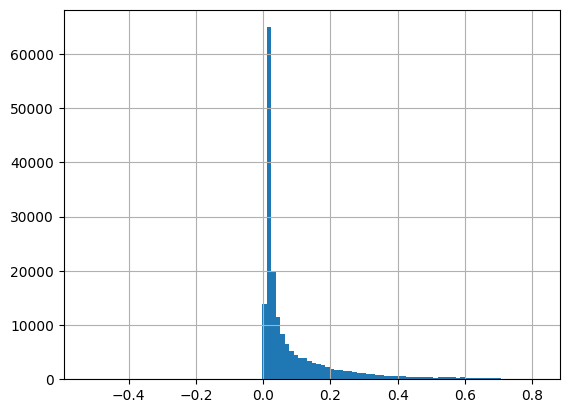

In [ ]:
df_scored["sentiment_score"].hist(bins=100)

In [ ]:
topic_sentiment.tail(10)

NameError: name 'topic_sentiment' is not defined

In [ ]:
topic_sentiment_clean = topic_sentiment[topic_sentiment["topic"] != -1]

In [ ]:
df_scored["date"] = pd.to_datetime(df_scored["date"])

daily_sentiment = (
    df_scored
    .groupby(["date", "topic_name"], as_index=False)
    .agg(
        mean_sentiment=("sentiment_score", "mean"),
        n_articles=("sentiment_score", "size"),
    )
)

daily_sentiment.head()

,date,topic_name,mean_sentiment,n_articles
0,2022-01-01,Outliers,-0.034916,5
1,2022-01-02,Developer Tools & Productivity Apps,0.032700,1
2,2022-01-02,Outliers,0.049245,2
3,2022-01-03,AI Image Generation & Creative Tools,0.010953,1
4,2022-01-03,Middle East Financial Markets,0.068210,1


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

KeyboardInterrupt: 

In [ ]:
df_scored = pd.read_parquet('/content/drive/MyDrive/NLP Final Project/ai_news_sentiment.parquet')

In [ ]:
df_scored.columns

Index(['url', 'date', 'title', 'clean_text', 'topic', 'topic_name',
       'sentiment_id', 'sentiment_label', 'prob_negative', 'prob_neutral',
       'prob_positive', 'confidence', 'sentiment_score'],
      dtype='object')

In [ ]:
# Your provided mapping
topic_labels = {
    0: "AI Image Generation & Creative Tools",
    1: "U.S. Federal Politics",
    2: "Clinical Research & Biotech",
    3: "Crypto Trading & Market Tools",
    4: "Startups & Venture Ecosystem",
    5: "Stock Markets & Earnings",
    6: "Regional Media & Press Distribution",
    7: "Indian National Politics",
    8: "Press Release Distribution Services",
    9: "Smartphones & Consumer Devices",
    10: "Public Broadcasting & Arts Media",
    11: "ChatGPT & AI Tools",
    12: "Chinese AI & Tech Competition",
    13: "Semiconductors & GPUs",
    14: "Climate & Renewable Energy",
    15: "Middle East Financial Markets",
    16: "Cybersecurity & Threat Intelligence",
    17: "OpenAI Leadership & Governance",
    18: "AI Copyright & Legal Disputes",
    19: "Developer Tools & Productivity Apps",
    20: "E-Commerce & Conversational AI",
    21: "Music Streaming & Digital Music Industry",
    22: "Crypto & Stock Investing (NFTs / Pharma / E-commerce)",
    23: "Texas Local News & Policy Updates",
    24: "Data Science Salaries & Recruiting",
    25: "Academic Integrity & ChatGPT in Education",
    26: "Entertainment Industry & Studios (SAG-AFTRA / Marvel)",
    27: "Google AI Ecosystem (Gemini / Android / Pixel)",
    28: "Generative Video Tools (Sora / Firefly / Text-to-Video)",
    29: "Automotive Engineering & Logistics",
    30: "Data Science Education & Skills",
    31: "West African Regional News",
    32: "New Mexico Local News",
    33: "Website Access & Login Systems",
    34: "Equities Markets & Stock Analysis",
    35: "Microsoft Copilot & Consumer Tech",
    36: "Dating, Mental Health & Relationships",
    37: "Legal Affairs & Financial Regulation",
    38: "Singapore News & Lifestyle Media",
    39: "Mobile Devices & Consumer Gadgets",
    40: "Home Electronics & Appliances",
    41: "Travel & Seasonal Lifestyle Content",
    42: "Global Sports & Premier League",
    43: "UAE Business & Regional Economy",
    44: "Philanthropy & Nonprofit Initiatives",
    45: "AI Content Creation & Enterprise Tools",
    46: "Public Radio & Cultural Programming",
    47: "Crypto Exchanges & Token Markets",
    48: "China Chip Exports & Trade Controls",
    49: "Crypto Technical Analysis & Indicators",
    50: "Telecom Industry & Sustainability Insights",
    51: "Forex Trading & Gold Markets",
    52: "Elon Musk, xAI & Grok AI",
    53: "Tech Bulletins & Educational Resources",
    54: "Crypto Price Forecasting & Volatility",
    55: "Restaurants & Food Industry",
    56: "Catholic Church & Vatican Affairs",
    57: "Canadian Regional News",
    58: "Central Asia Energy & Geopolitics",
    59: "Idaho Public Media & Local News",
    60: "Maryland & Virginia Community News",
    61: "Tesla, SpaceX & AI Robotics",
    62: "Enterprise Consulting & Digital Transformation",
    63: "The Beatles & Classic Rock Media",
    64: "Gaming Platforms & Security Updates",
    65: "Colorado Local News & Weather",
    66: "Pakistan National News",
    67: "Digital Art & Creative Design",
    68: "Sports Betting & Gambling Industry",
    69: "Gaza Conflict & Middle East War",
    70: "AI Assistants & Regional Tech News",
    71: "Asian Wellness & Lifestyle Media",
    72: "Macro Markets, Fed & Crypto",
    73: "Louisiana Regional News",
    74: "Voice Cloning & Fraud Risks",
    75: "Religious Tolerance & Human Rights",
    76: "Midwest Public Radio & Community News",
    77: "Ohio Regional News & Politics",
    78: "UK Soap Operas & Showbiz",
    79: "Air India & Aviation Incidents",
    80: "Florida Regional News & Economy",
    81: "FinTech Innovation & Digital Banking",
    82: "African Digital Markets & Monthly Reports",
    83: "Voice AI & Audio Generation Tools",
    84: "Smart Glasses & Wearable Tech",
    85: "Real Estate & Property Management",
    86: "OpenAI Voice Controversy & IP",
    87: "Tennessee & West Virginia Regional News",
    88: "Maine Public Broadcasting",
    89: "School Security & Public Safety",
    90: "Investment Analysis & Market Gurus",
    91: "Travel Industry & Hospitality",
    92: "Google Search & SEO Overviews",
    93: "Gaming Consoles & Streaming Platforms",
    94: "Business Conferences & Industry Summits",
    95: "Regional Media & Business News",
    96: "Child Safety & Abuse Prevention",
    97: "Cloud, APIs & DevOps Infrastructure",
    98: "Midwest Arts & Public Radio",
    -1: "Outliers"
}

# Map to new column
df_scored["topic_name"] = df_scored["topic"].map(topic_labels)

# Safety check for unmapped topics
missing = df_scored[df_scored["topic_name"].isna()]["topic"].unique()
print("Unmapped topic IDs:", missing)

Unmapped topic IDs: [158 141 106 108  99 128 133 101 153 146 132 102 139 125 111 103 130 122
 142 113 123 140 105 117 143 100 116 126 161 127 134 110 145 112 159 114
 154 150 109 104 131 149 115 151 119 157 135 107 118 144 147 124 160 138
 121 156 136 129 148 155 152 137 120]


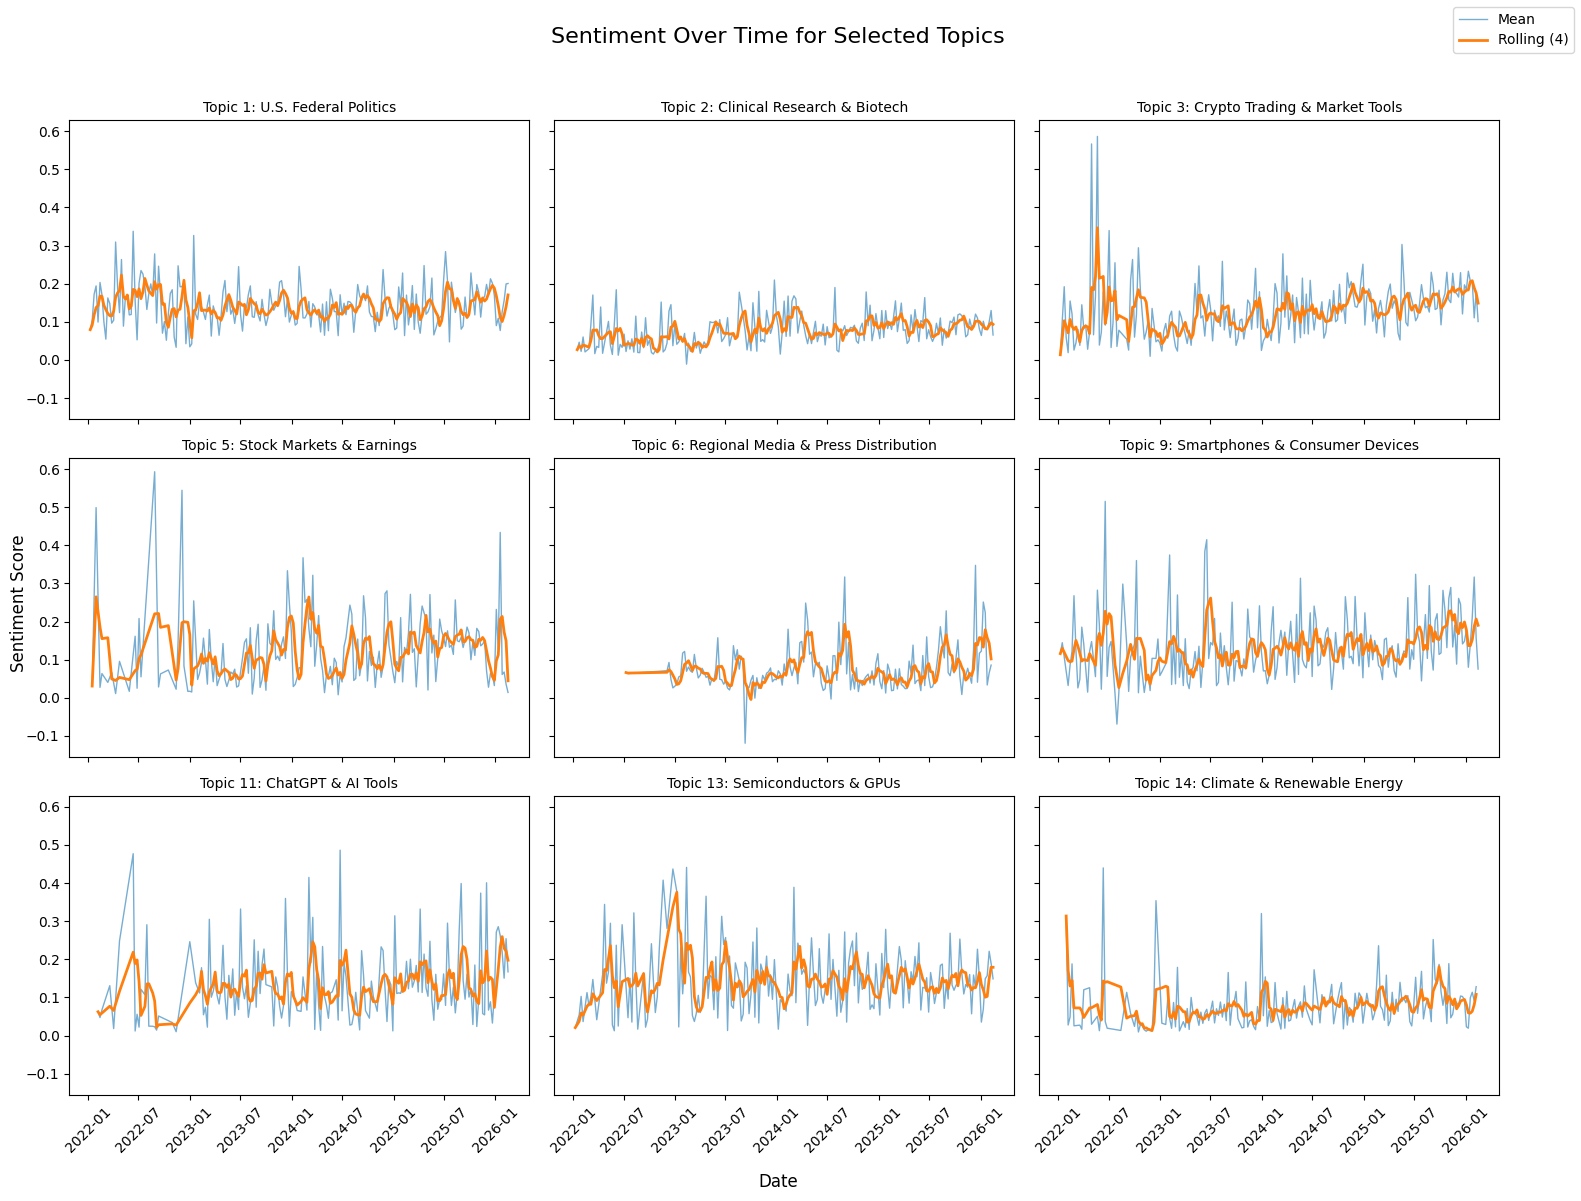

In [ ]:
import matplotlib.pyplot as plt

# Topics to visualize
selected_topics = [1, 2, 3, 5, 6, 9, 11, 13, 14]

df_sel = topic_time[topic_time["topic"].isin(selected_topics)].copy()

# --------------------------------
# 3 × 3 subplot
# --------------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

grouped = list(df_sel.groupby(["topic", "topic_name"]))

for ax, ((tid, tname), g) in zip(axes, grouped):

    g = g.sort_values("date").copy()
    g["mean_sent_roll"] = g["mean_sent"].rolling(ROLL, min_periods=1).mean()

    ax.plot(g["date"], g["mean_sent"], alpha=0.6, linewidth=1, label="Mean")
    ax.plot(g["date"], g["mean_sent_roll"], linewidth=2, label=f"Rolling ({ROLL})")

    ax.set_title(f"Topic {tid}: {tname}", fontsize=10)
    ax.tick_params(axis="x", rotation=45)

# shared labels
fig.suptitle("Sentiment Over Time for Selected Topics", fontsize=16)
fig.supxlabel("Date")
fig.supylabel("Sentiment Score")

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout(rect=[0,0,0.96,0.96])
plt.show()

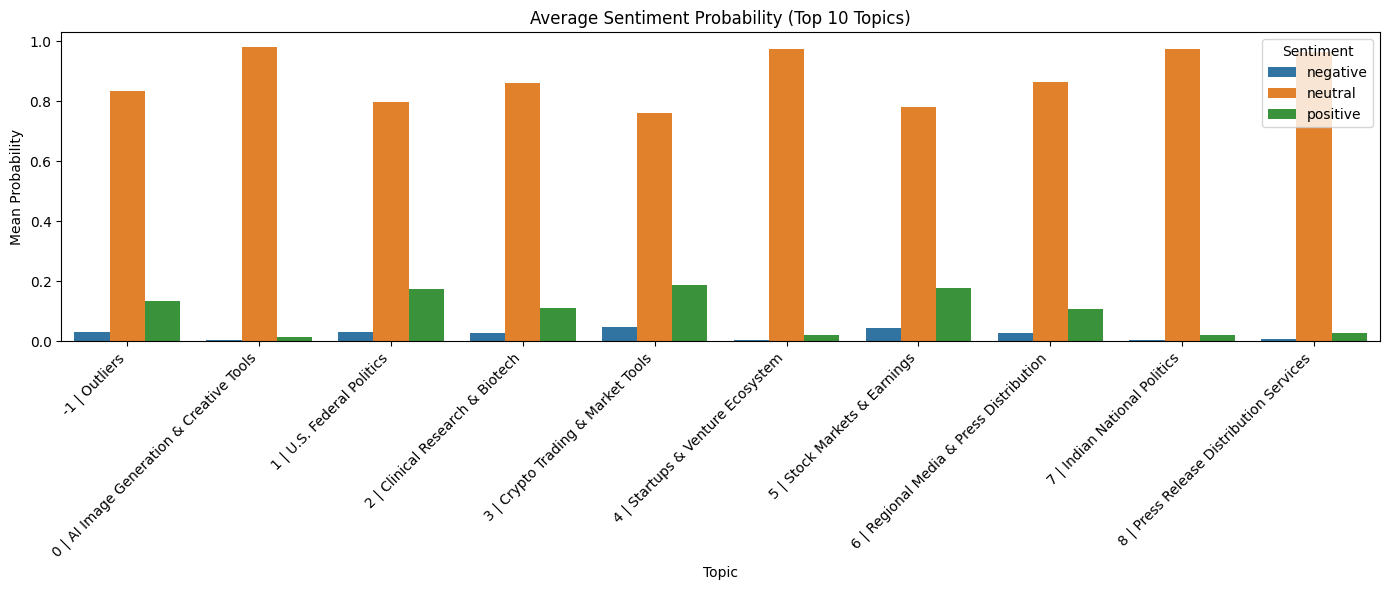

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

TOP_K = 10

# -----------------------
# 1) Select top 10 topics
# -----------------------
top_topics = (
    df_scored["topic"]
    .value_counts()
    .head(TOP_K)
    .index
)

df_top = df_scored[df_scored["topic"].isin(top_topics)].copy()

df_top["topic_label"] = (
    df_top["topic"].astype(str) + " | " +
    df_top["topic_name"].astype(str).str.slice(0, 40)
)

# -----------------------
# 2) Aggregate means
# -----------------------
agg = (
    df_top.groupby("topic_label")[
        ["prob_negative", "prob_neutral", "prob_positive"]
    ]
    .mean()
    .reset_index()
)

# Melt for plotting
df_long = agg.melt(
    id_vars="topic_label",
    var_name="sentiment_type",
    value_name="mean_probability"
)

df_long["sentiment_type"] = df_long["sentiment_type"].str.replace("prob_", "")

# -----------------------
# 3) Plot
# -----------------------
plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_long,
    x="topic_label",
    y="mean_probability",
    hue="sentiment_type"
)

plt.xticks(rotation=45, ha="right")
plt.title("Average Sentiment Probability (Top 10 Topics)")
plt.xlabel("Topic")
plt.ylabel("Mean Probability")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [ ]:
df_scored['topic_name'].value_counts()

,count
topic_name,
Outliers,90996
AI Image Generation & Creative Tools,7884
U.S. Federal Politics,4052
Clinical Research & Biotech,3131
Crypto Trading & Market Tools,2246
Startups & Venture Ecosystem,2087
Stock Markets & Earnings,1946
Regional Media & Press Distribution,1842
Indian National Politics,1774


In [ ]:
topic_sentiment = (
    df_scored
    .groupby(["topic", "topic_name"], as_index=False)
    .agg(
        n_articles=("sentiment_score", "size"),
        mean_sentiment=("sentiment_score", "mean"),
        std_sentiment=("sentiment_score", "std"),
    )
    .sort_values("mean_sentiment", ascending=False)
)

topic_sentiment.head(10)

,topic,topic_name,n_articles,mean_sentiment,std_sentiment
43,42,Global Sports & Premier League,537,0.284535,0.248416
27,26,Entertainment Industry & Studios (SAG-AFTRA / ...,909,0.238912,0.236452
58,57,Canadian Regional News,411,0.237151,0.208039
95,94,Business Conferences & Industry Summits,280,0.233033,0.216217
65,64,Gaming Platforms & Security Updates,371,0.209485,0.148946
51,50,Telecom Industry & Sustainability Insights,452,0.203515,0.236358
76,75,Religious Tolerance & Human Rights,331,0.187679,0.172638
77,76,Midwest Public Radio & Community News,330,0.187326,0.182226
44,43,UAE Business & Regional Economy,531,0.182820,0.173002
67,66,Pakistan National News,369,0.166328,0.176639


In [ ]:
topic_sentiment = (
    df_scored
    .groupby(["topic", "topic_name"], as_index=False)
    .agg(
        n_articles=("sentiment_score", "size"),
        mean_sentiment=("sentiment_score", "mean"),
        std_sentiment=("sentiment_score", "std"),
    )
    .sort_values("mean_sentiment", ascending=False)
)

topic_sentiment.tail(10)

,topic,topic_name,n_articles,mean_sentiment,std_sentiment
84,83,Voice AI & Audio Generation Tools,308,0.015237,0.021232
42,41,Travel & Seasonal Lifestyle Content,542,0.014819,0.005273
64,63,The Beatles & Classic Rock Media,372,0.014727,0.016645
97,96,Child Safety & Abuse Prevention,279,0.013405,0.007749
30,29,Automotive Engineering & Logistics,848,0.012645,0.013374
48,47,Crypto Exchanges & Token Markets,506,0.012573,0.015356
1,0,AI Image Generation & Creative Tools,7884,0.012012,0.016315
54,53,Tech Bulletins & Educational Resources,431,0.010303,0.007814
81,80,Florida Regional News & Economy,315,0.009715,0.000264
38,37,Legal Affairs & Financial Regulation,621,0.009473,0.002385


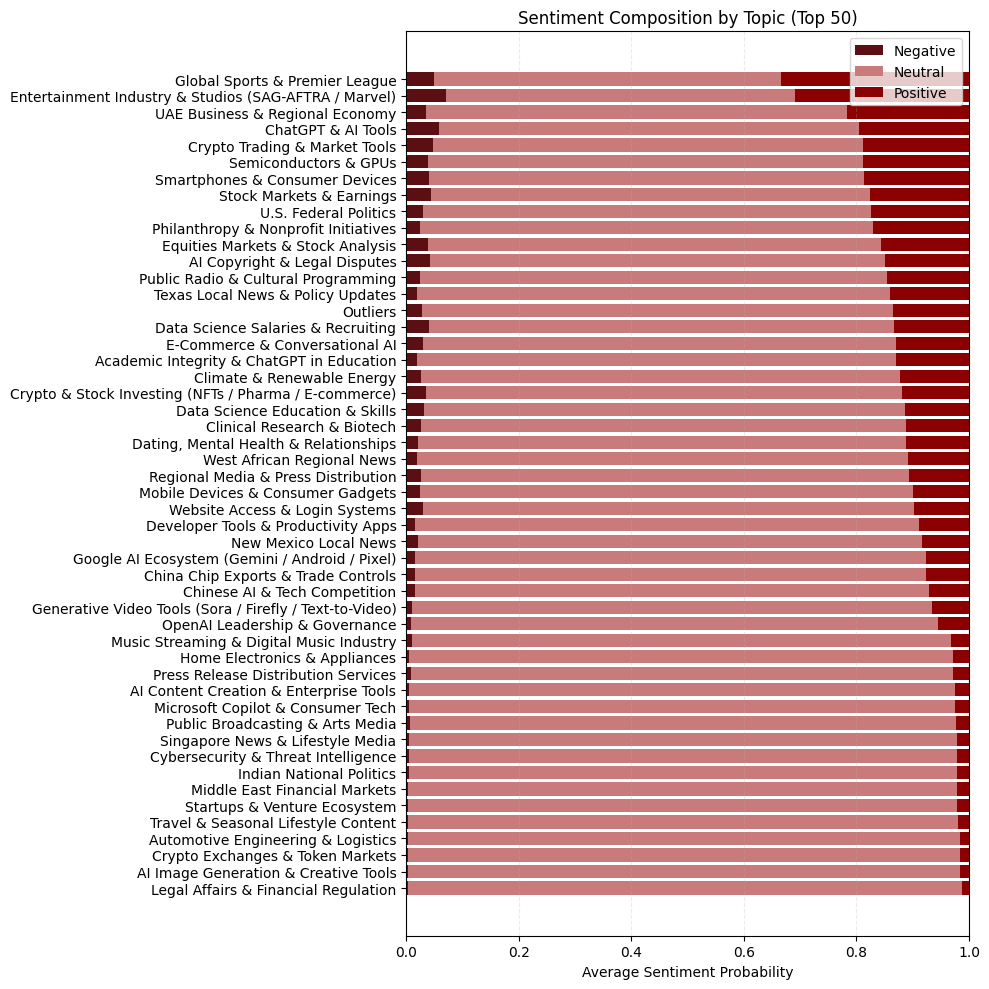

In [ ]:
# ----------------------------
# 3) Dark Red Palette
# ----------------------------
NEG_COLOR = "#5b0f12"   # deep burgundy
NEU_COLOR = "#c97b7b"   # muted rose
POS_COLOR = "#8b0000"   # dark red

# ----------------------------
# 4) Plot Stacked Bars
# ----------------------------
plt.figure(figsize=(10,10))

y = topic_probs["topic_name"]

neg = topic_probs["prob_negative"]
neu = topic_probs["prob_neutral"]
pos = topic_probs["prob_positive"]

plt.barh(y, neg, color=NEG_COLOR, label="Negative")
plt.barh(y, neu, left=neg, color=NEU_COLOR, label="Neutral")
plt.barh(y, pos, left=neg + neu, color=POS_COLOR, label="Positive")

plt.xlabel("Average Sentiment Probability")
plt.title("Sentiment Composition by Topic (Top 50)")

plt.xlim(0,1)

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

Positive texts: 25438
Negative texts: 616


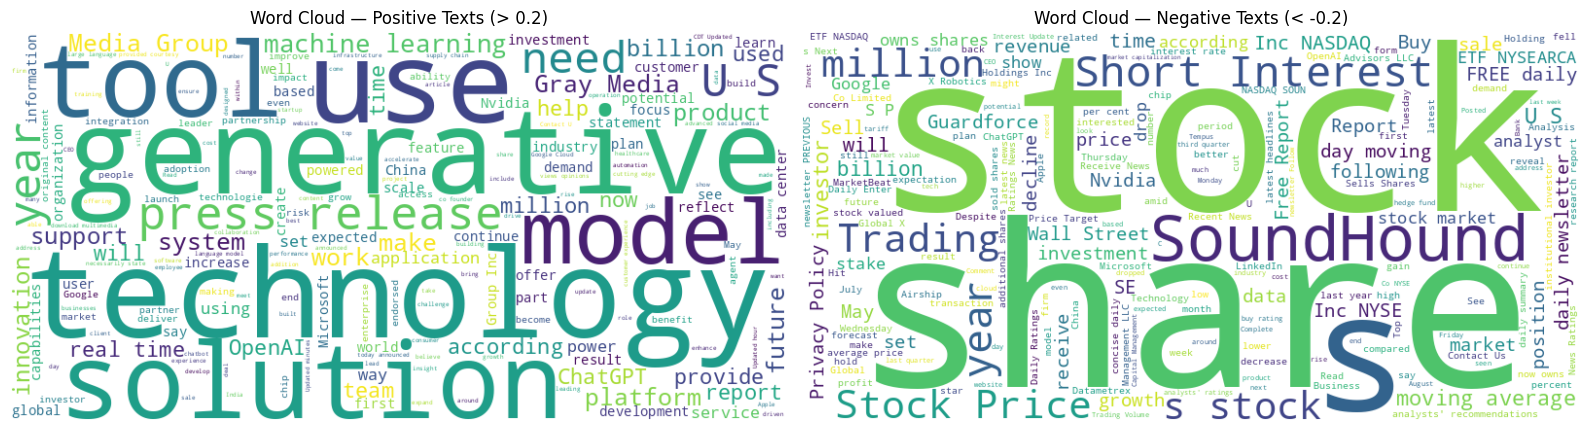

In [ ]:
!pip -q install wordcloud

import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re

# -------------------------
# 1) Define thresholds
# -------------------------
POS_THRESH = 0.2
NEG_THRESH = -0.1

# -------------------------
# 2) Select texts
# -------------------------
df_pos = df_scored[df_scored["sentiment_score"] > POS_THRESH]
df_neg = df_scored[df_scored["sentiment_score"] < NEG_THRESH]

print("Positive texts:", len(df_pos))
print("Negative texts:", len(df_neg))

# Combine title + body
text_pos = " ".join((df_pos["title"].fillna("") + " " + df_pos["clean_text"].fillna("")).tolist())
text_neg = " ".join((df_neg["title"].fillna("") + " " + df_neg["clean_text"].fillna("")).tolist())

# Optional: extend stopwords
custom_stopwords = STOPWORDS.union({
    "said", "would", "also", "one", "new",
    "ai", "artificial", "intelligence",
    "company", "companies"
})

# -------------------------
# 4) Generate word clouds
# -------------------------
wc_pos = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=custom_stopwords,
    max_words=200
).generate(text_pos)

wc_neg = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=custom_stopwords,
    max_words=200
).generate(text_neg)

# -------------------------
# 5) Plot side-by-side
# -------------------------
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_pos, interpolation="bilinear")
plt.title("Word Cloud — Positive Texts (> 0.2)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(wc_neg, interpolation="bilinear")
plt.title("Word Cloud — Negative Texts (< -0.2)")
plt.axis("off")

plt.tight_layout()
plt.show()